**Requisito 1:** montagem do grafo a partir das seguintes 3 páginas: "Ponta Negra (Natal)", "Centro de Lançamento da Barreira do Inferno", "Pico do Cabugi".

As stop-words utilizadas foram as mesmas expostas no notebook da semana 9, sem acréscimos.

Ressalta-se que, por questões de tempo de processamento, o nível de profundidade da rede foi limitado a 2.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving RN_rdy.graphml to RN_rdy.graphml


In [20]:
!pip install wikipedia networkx matplotlib seaborn

import wikipedia
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Seeds - as 3 páginas iniciais
SEEDS = ["Ponta Negra (Natal)", "Centro de Lançamento da Barreira do Inferno", "Pico do Cabugi"]

# Stop words - black list de palavras nos links
STOPS = ("International Standard Serial Number",
         "International Standard Book Number",
         "National Diet Library",
         "International Standard Name Identifier",
         "International Standard Book Number (Identifier)",
         "Pubmed Identifier",
         "Pubmed Central",
         "Digital Object Identifier",
         "Arxiv",
         "Proc Natl Acad Sci Usa",
         "Bibcode",
         "Library Of Congress Control Number",
         "Jstor",
         "Doi (Identifier)",
         "Isbn (Identifier)",
         "Pmid (Identifier)",
         "Arxiv (Identifier)",
         "Bibcode (Identifier)")

In [22]:
# Listas - done_set: páginas já processadas; todo_lst: páginas que falta processar; todo_set: pra verificar se uma página já foi processada
todo_lst = [(0, seed) for seed in SEEDS]  # The SEED is in the layer 0
todo_set = set(SEEDS)  # The SEED itself
done_set = set()  # Nothing is done yet

# Inicializando o grafo
g = nx.DiGraph()


In [23]:
while todo_lst:
    layer, page = todo_lst[0]

    # Ignorando os layers 2+
    if layer >= 2:
        break

    # Remove a página atual da todo_lst e adiciona à done_set (não será visitada se encontrada novamente)
    del todo_lst[0]
    done_set.add(page)

    # Download da página
    try:
        wiki = wikipedia.page(page)
    except:
        print("Could not load", page)
        continue

    # Adicionando os links ao grafo
    for link in wiki.links:
        link = link.title()
        if link not in STOPS and not link.startswith("List Of"):
            if link not in todo_set and link not in done_set:
                todo_lst.append((layer + 1, link))
                todo_set.add(link)
            g.add_edge(page, link)

/usr/local/lib/python3.10/dist-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /usr/local/lib/python3.10/dist-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


Could not load Beach
Could not load Dune
Could not load Praia Dos Artistas
Could not load Punta Negra (Disambiguation)
Could not load Geomet-1
Could not load Koroni
Could not load Outer Space
Could not load Paiute Tomahawk
Could not load Ponta Negra
Could not load Rocket Lab
Could not load Sgdc
Could not load Vls-1
Could not load Vs-15
Could not load Vs-40


In [24]:
# Criando uma copia do grafo
original = g.copy()

# Remove self-loops
g.remove_edges_from(nx.selfloop_edges(g))

# Identificando duplicatas do tipo palavra + plural
duplicates = [(node, node + "s") for node in g if node + "s" in g]

for dup in duplicates:
    g = nx.contracted_nodes(g, *dup, self_loops=False)

# Identificando duplicatas do tipo palavra + hífen
duplicates = [
    (x, y)
    for x, y in [(node, node.replace("-", " ")) for node in g]
    if x != y and y in g
]

for dup in duplicates:
    g = nx.contracted_nodes(g, *dup, self_loops=False)

nx.set_node_attributes(g, 0, "contraction")
nx.set_edge_attributes(g, 0, "contraction")

# Filtrando nós com grau >= 2
core = [node for node, deg in dict(g.degree()).items() if deg >= 2]

# Selecionando um subgrafo com os nós core
gsub = nx.subgraph(g, core)

# Salvando o grafo
nx.write_graphml(gsub, "RN.graphml")

Após isso, analisou-se o grafo no gephi para obter as métricas desejadas. A principio, na aba statistics, calculou-se o average degree do grafo e em seguida a modularity, informando a existência de 9 comunidades. Utilizando o layout ForceAtlas2, pintou-se os nós com base em quais comunidades eles pertencem e alterou-se o tamanho dos nós deles com base no in-degree, destacando os nós mais citados.

<ipython-input-25-633fbf4a6f00>:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


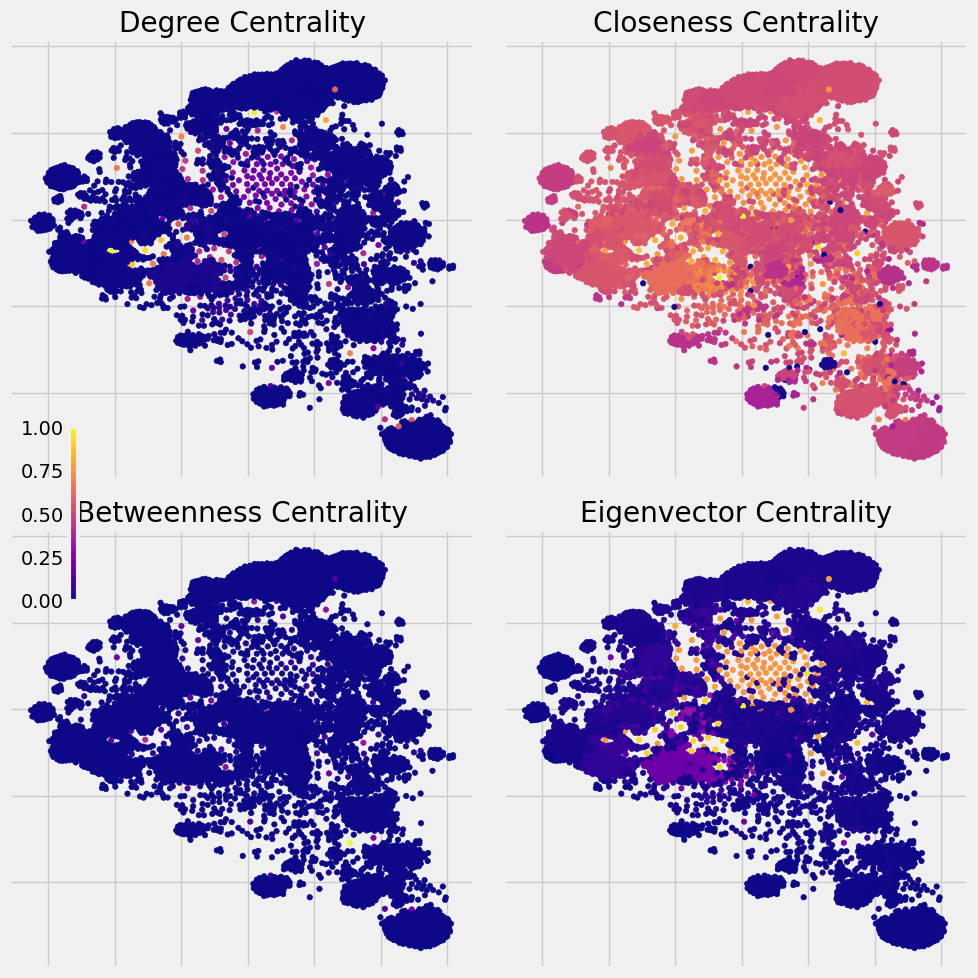

In [25]:
# Carregando o grafo já editado no Gephi
G = nx.read_graphml("RN_rdy.graphml")

# Coletando posições dos nós
pos = {}
for node in G.nodes:
    try:
        x = float(G.nodes[node]['x'])
        y = float(G.nodes[node]['y'])
        pos[node] = (x, y)
    except KeyError:
        # Ignorando nós sem coordenadas
        pass

# Criando grafo apenas com nós que possuem coordenadas
G_cords = G.subgraph(pos.keys())

# Calculando métricas de centralidades
degree_cent = nx.degree_centrality(G_cords)
close_cent = nx.closeness_centrality(G_cords)
between_cent = nx.betweenness_centrality(G_cords)
eigen_cent = nx.eigenvector_centrality(G_cords)

# 2 linhas, 2 colunas
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
cmap = plt.cm.plasma

# Plotando Degree Centrality
nx.draw_networkx(G_cords, pos, node_color=list(degree_cent.values()), cmap=cmap, ax=axs[0, 0], with_labels=False, node_size=15, edgelist=[])
axs[0, 0].set_title('Degree Centrality')

# Plotando Closeness Centrality
nx.draw_networkx(G_cords, pos, node_color=list(close_cent.values()), cmap=cmap, ax=axs[0, 1], with_labels=False, node_size=15, edgelist=[])
axs[0, 1].set_title('Closeness Centrality')

# Plotando Betweenness Centrality
nx.draw_networkx(G_cords, pos, node_color=list(between_cent.values()), cmap=cmap, ax=axs[1, 0], with_labels=False, node_size=15, edgelist=[])
axs[1, 0].set_title('Betweenness Centrality')

# Plotando Eigenvector Centrality
nx.draw_networkx(G_cords, pos, node_color=list(eigen_cent.values()), cmap=cmap, ax=axs[1, 1], with_labels=False, node_size=15, edgelist=[])
axs[1, 1].set_title('Eigenvector Centrality')

# Adicionando a barra de cor
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.01, location='left')

plt.tight_layout()
plt.savefig('centralitys.png', transparent=True,dpi=300)
plt.show()

**Requisito 2:** feitos os cálculos por meio da biblioteca networkX das métricas de centralidades e seus devidos plots, infere-se:

no plot do degree centrality, percebe-se que a parte majoritaria da rede possui a cor azul escuro, indicando que a maioria das páginas não são citadas (como se fossem nós folhas de uma árvore). Destaca-se também a presença de um grupo de nós com maior quantidade de citações, com cor roxa, e nós isolados com grande quantidades de citações, de cor amarelada, espalhados pelo grafo, que são os hubs;

no plot do closeness centrality, percebe-se que boa parte da rede possui um grau médio de distância média entre a maioria dos nós, com um grupo de cor mais alaranjada com um grau de proximidade maior, e visivelmente mais distantes dos nós que cercam esse grupo;

no plot do betweenness centrality, percebe-se que praticamente a rede inteira está com a mesma cor azul escura, indicando que pouquissimos nós atuam como pontes críticas na rede, ou seja, os caminhos mais curtos entre nós não dependem fortemente de nós específicos;

no plot do eigenvector centrality, percebe-se que apesar da parte majoritária da rede ter nós de baixa centralidade (cor azul escuro), há grupos com cores mais quentes de maior centralidade e, portanto, influência e conectividade. Destaca-se também a presença de nós com elevadissimo valor de centralidade, de cor amarela, pelo grafo, atuando como Hubs.


**Requisito 3:** gerou-se gráficos acerca da função de densidade de probabilidade e de função de densidade acumulada, considerando o in-degree dos *nós* da rede.

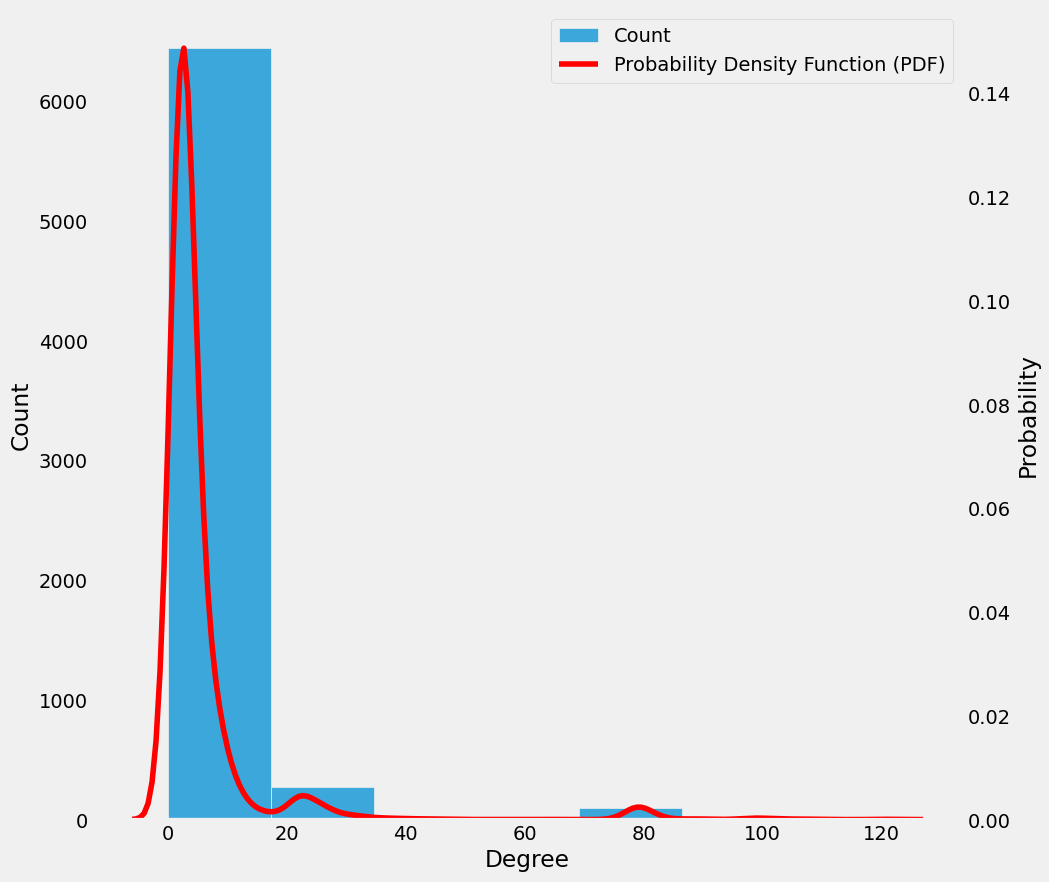

In [26]:
# Calculando in-degree dos nós (p/ PDF)
in_degrees = dict(G_cords.in_degree())
in_degree_sequence = list(in_degrees.values())

# Plotando gráfico
plt.style.use("fivethirtyeight")
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

sns.histplot(in_degree_sequence, bins=7, label="Count", ax=ax)
ax2 = ax.twinx()
sns.kdeplot(in_degree_sequence, color='r', label="Probability Density Function (PDF)", ax=ax2)

# ask matplotlib for the plotted objects and their labels
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc=0)

ax.grid(False)
ax2.grid(False)
ax.set_xlabel("Degree")
ax2.set_ylabel("Probability")
plt.savefig('PDF.png', transparent=True,dpi=600,bbox_inches="tight")
plt.show()

Perceptivelmente, há uma maioria de nós com baixo in-degree, indicando que a maior parte das páginas dessa rede são poucos citadas, havendo também um grupo menor com mais citações (em torno de 20) e um ainda menor grupo com grandes citações (em torno de 80). Percebe-se também uma minuscula quantidade de páginas com mais de 100 citações.

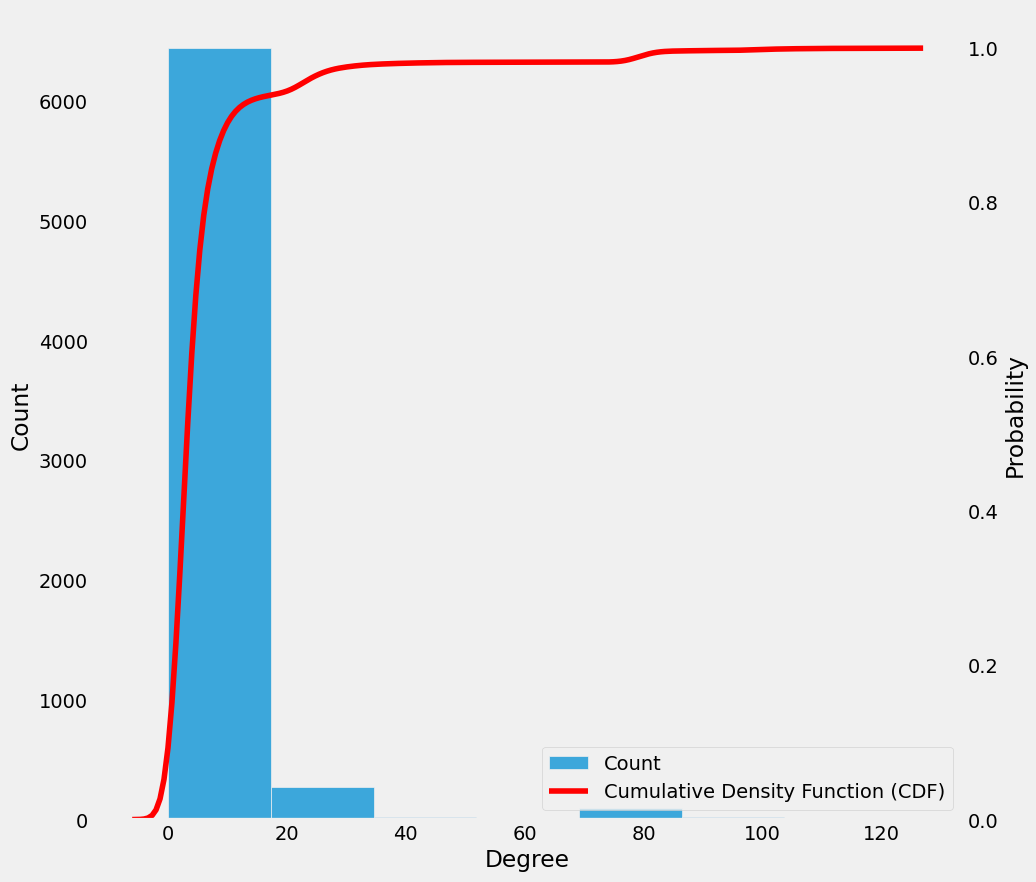

In [27]:
# Calculando in-degree dos nós (p/ CDF)
plt.style.use("fivethirtyeight")
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

sns.histplot(in_degree_sequence, bins=7, label="Count", ax=ax)
ax2 = ax.twinx()
sns.kdeplot(in_degree_sequence, color='r', label="Cumulative Density Function (CDF)", ax=ax2, cumulative=True)

# ask matplotlib for the plotted objects and their labels
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc=0)

ax.grid(False)
ax2.grid(False)
ax.set_xlabel("Degree")
ax2.set_ylabel("Probability")
plt.savefig('CDF.png', transparent=True,dpi=600,bbox_inches="tight")
plt.show()

Com a curva subindo bastante acelerada no inicio, confirmamos novamente a maioria de nós com baixo in-degree, e as oscilações na curva na marca de 20 citações e 80 citações, indicando 2 grupos menores com mais citações, como visto também na PDF.

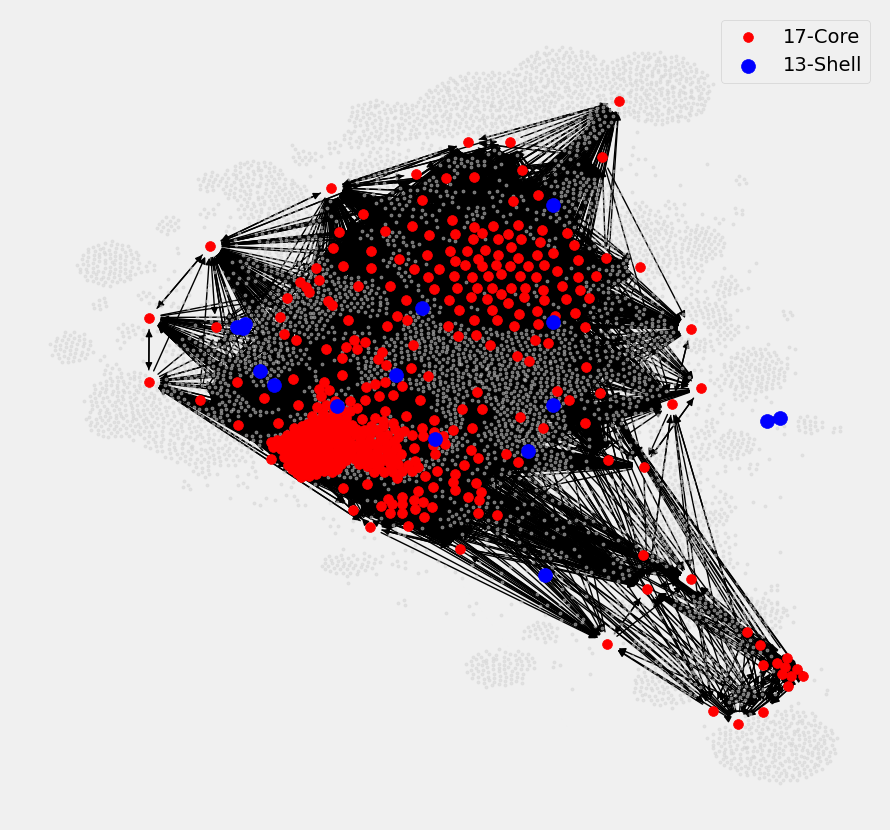

In [29]:
# Encontrando os k-cores
k_core = nx.k_core(G, 17)

# Encontrar os k-shells
k_shell = nx.k_shell(G, 13)

# Criar a figura
plt.style.use("fivethirtyeight")
fig, ax = plt.subplots(figsize=(10, 10))

# Desenhar o grafo original
nx.draw_networkx_nodes(G_cords, pos, node_size=5, node_color='lightgrey', alpha=0.5)

# Desenhar o k-core
nx.draw_networkx_nodes(k_core, pos, node_size=50, node_color='red', label=f"17-Core")
nx.draw_networkx_edges(k_core, pos, alpha=1.0)

# Desenhar o k-shell
nx.draw_networkx_nodes(k_shell, pos, node_size=100, node_color='blue', label=f"13-Shell")
nx.draw_networkx_edges(k_shell, pos, alpha=1.0)

# Adicionando legenda - 17-core; 13-shell
ax.legend()
ax.axis('off')
plt.savefig('k-cores.png', transparent=True,dpi=600)
plt.show()

**Requisito 4:** os nós em vermelho representam os 17-core da rede ao passo que os azuis representam os 13-shell da rede. Percebe-se, portanto, que há uma quantidade significativa de nós com vizinhos com pelo menos 17 conexões, possivelmente atuando como hubs para a rede. Os nós em azul são os nós que pertencem ao 13-core, mas não pertencem ao 14-core, por isso o nome shell, indicando que estão na extremidade do próximo core.

**Requisito 5:** após a edição no Gephi, fez-se a [visualização da rede em produção](https://ouestware.gitlab.io/retina/beta/#/graph/?url=https%3A%2F%2Fgist.githubusercontent.com%2Fjosemartins36%2F46adf54e7db910bdfaf642f9e3197a8c%2Fraw%2F79ee01035e72d6ff65e5a05f82a1faac1ebcdd6c%2FRN_rdy.graphml&sa%5B%5D=co&sa%5B%5D=ei&sa%5B%5D=r&ca%5B%5D=i-s&ca%5B%5D=o-s&ca%5B%5D=d-s&ca%5B%5D=m-s&ca%5B%5D=ec-s&ca%5B%5D=cl-s&ca%5B%5D=h-s&ca%5B%5D=b-s), com as cores relacionadas ao critério de
modularity e o tamanho do vértice a métrica in-degree.